In [3]:
import numpy as np
import scipy as sp
from scipy.sparse import linalg
import pandas as pd
import pyansys
from tqdm.notebook import tqdm
from scipy import spatial

import sys
import pyvista as pv

sys.path.insert(1, '../')
import pyFBS
from pyFBS.utility import *

In [4]:
def import_data_from_ANSYS(path_to_rst_file, path_to_full_file, return_rst_and_full=False):
    """
    Read data from Ansys files .rst and .full.
    
        :param path_to_rst_file: location of the .rst file exported from Ansys
        :type path_to_rst_file: str
        :param path_to_full_file: location of the .full file exported from Ansys
        :type path_to_full_file: str
        :param return_rst_and_full: function returns also .rst (pyansys.rst.ResultFile) and .full files (pyansys.full.FullFile)
        :type return_rst_and_full: bool
        :return: M, K, nodes, dof_ref, elem, rotation_included(, rst, full)-> if return_rst_and_full==True
        :rtype: (array(float, sparce format), array(float, sparce format), array(float), array(int), array(int), bool, (pyansys.rst.ResultFile), (pyansys.full.FullFile))
    """
    
    path_to_rst_file = r"{}".format(path_to_rst_file)
    path_to_full_file = r"{}".format(path_to_full_file)
    
    rst = pyansys.read_binary(path_to_rst_file)
    nodes = rst.geometry["nodes"][:,0:3] # only translational dofs

    full = pyansys.read_binary(path_to_full_file)
    dof_ref, K, M = full.load_km(sort=True) # dof_ref: 0-x 1-y 2-z

    M += sp.sparse.triu(M, 1).T
    K += sp.sparse.triu(K, 1).T
    
    # index_sort = np.argsort(rst.geometry["enum"])
    # elem = rst.geometry["elem"][index_sort]
    
    elem = rst.geometry["elem"]
    _bool = elem != -1
    elem_=[]
    for e, b in zip(elem, _bool):
        _ = e[b]
        elem_.append(np.hstack([len(_), _-1]))
    elem = np.concatenate(elem_).ravel()
    
    rotation_included = False
    if rst.resultheader["numdof"] == 6: # check if rotation is included in node DoFs
        rotation_included = True
        
    if return_rst_and_full:
        return M, K, nodes, dof_ref, elem, rotation_included, rst, full
    else:
        return M, K, nodes, dof_ref, elem, rotation_included

In [5]:
def visualsation_3D(nodes, elem, **kwargs):
    """
    Generate basic 3D window for visualisation of mode shapes or locations of excitations and responses. 
    
        :param nodes: locations of nodes of observed system
        :type nodes: array(float)
        :param elem: definitions of finite elements, connections between nodes. 
        :type elem: array(int)
        :return: view3D
        :rtype: (pyFBS.display.view3D)
    
    """
    view3D = pyFBS.display.view3D(show_origin= True)
    # Priprava objekta za 3D prikaz
    point_cloud = pv.PolyData(nodes*1000, elem)
    mesh_actor = view3D.plot.add_mesh(point_cloud, scalars = np.zeros(point_cloud.points.shape[0]), point_size=10,
                                      show_edges=True,color = "k", name = "mesh", **kwargs)#,render_points_as_spheres = True,point_size=20)
    return view3D

def show_mode(view3D, dof_ref, eig_vec, eig_freq, select_mode, relative_scale):
    """
    Show the animation of desired mode shape.
    
        :param view3D: object (pyFBS.display.view3D) presenting the base for showing mode shape.
        :type view3D: (pyFBS.display.view3D)
        :param dof_ref: definitions of DoFs of all defined nodes 
        :type dof_ref: array(int)
        :param eig_vec: eigen vectors of analysed structure
        :type eig_vec: array(float)
        :param eig_freq: eigen frequncies of analysed structure
        :type eig_freq: array(float)
        :param select_mode: number of mode to show
        :type select_mode: int
        :param relative_scale: amplification of deformations in mode shape animation
        :type relative_scale: float
        :return: None
        :rtype: None
    
    """
    #kreairanje animacije
    _modeshape = np.zeros((nodes.shape[0], dof_ref[:, 1].max()+1))
    for ref,mode in zip(dof_ref,eig_vec[:,select_mode]):
        _modeshape[ref[0]-1,ref[1]] = mode

    #samo priprava vsega za onimacijo v pyFBSu
    mode_dict = dict()
    one_mode = _modeshape[:, :nodes.shape[1]]
    mode_dict["animation_pts"] = mode_animation(one_mode,relative_scale,no_points = 60)
    mode_dict["mesh"] = view3D_modeshape.plot.mesh
    mode_dict["or_pts"] = view3D.plot.mesh.points.copy()
    mode_dict["scalars"] = True
    mode_dict["fps"] = 30
    mode_dict["freq"] = eig_freq[select_mode]/(2*np.pi)
#     mode_dict["damp"] = damping[select_mode]
    Sxx=np.real(one_mode).T@np.real(one_mode)
    Syy=np.imag(one_mode).T@np.imag(one_mode)
    Sxy=np.real(one_mode).T@np.imag(one_mode)
    mcf = 1 - ((Sxx-Syy)**2 + 4*Sxy**2)/((Sxx+Syy)**2)
    mcf = np.average(np.diag(mcf))
    mode_dict["mcf"] = mcf
    
    # add animation to window
    view3D.add_modeshape(mode_dict,run_animation = True, add_note = False)

In [6]:
def find_nearest_locations(dense_mesh_points, sparse_mesh_points, dense_mesh_node_id=None):
    """ 
    This function finds the nearest coordinate locations of sparse mesh in the corresponding dense mesh.
        :param dense_mesh_points: nodal coordinates of dense mesh in 3D space
        :type dense_mesh_points: array
        :param sparse_mesh_points: nodal coordinates of sparse mesh in 3D space
        :type sparse_mesh_points: array
        :param dense_mesh_node_id: nodal coordinates id of sparse mesh
        :type dense_mesh_node_id: array
        :return: Selected nodes by index and by id regarding the dense mesh
        :rtype: (array(int), array(int))
    
    """
    tree = spatial.KDTree(list(zip(dense_mesh_points[:, 0].ravel(), dense_mesh_points[:, 1].ravel(), dense_mesh_points[:, 2].ravel())))
    selected_dense_mesh_node_index = (tree.query(sparse_mesh_points))[1] 
    
    if not (dense_mesh_node_id is None):
        selected_dense_mesh_node_id = dense_mesh_node_id[selected_dense_mesh_node_index]
        selected_dense_mesh_node_id = list(map(int, selected_dense_mesh_node_id))
        return selected_dense_mesh_node_index, selected_dense_mesh_node_id
    else:
        return selected_dense_mesh_node_index

# Data import

### Dense mesh

In [7]:
path_to_rst_file = r"../data/LADISK_example_mesh_ANSYS/DenseMesh/file.rst"
path_to_full_file = r"../data/LADISK_example_mesh_ANSYS/DenseMesh/file.full"
M, K, nodes, dof_ref, elem, rotation_included = import_data_from_ANSYS(path_to_rst_file, path_to_full_file, return_rst_and_full=False)

In [19]:
rst = pyansys.read_binary(path_to_rst_file)

type(rst.grid)

pyvista.core.pointset.UnstructuredGrid

In [17]:
rst.grid.points *= 1000

view3D = pyFBS.display.view3D(show_origin= True)

view3D.plot.add_mesh(rst.grid, scalars = np.zeros(rst.grid.points.shape[0]),show_scalar_bar = False,show_edges = True)



(vtkRenderingOpenGL2Python.vtkOpenGLActor)0000024868701DC8

### Sparse mesh

In [6]:
path_to_rst_file = r"../data/LADISK_example_mesh_ANSYS/SparseMesh/file.rst"
path_to_full_file = r"../data/LADISK_example_mesh_ANSYS/SparseMesh/file.full"
nodes_sparse, elem_sparse = np.asarray(import_data_from_ANSYS(path_to_rst_file, path_to_full_file, return_rst_and_full=False))[[2, 4]]

In [7]:
selected_dense_mesh_node_index = find_nearest_locations(dense_mesh_points = nodes, sparse_mesh_points = nodes_sparse)

# EIGENVALUE PROBLEM

In [8]:
def eig_solve(mass_mat, stiff_mat, no_modes):
    """
    Solve eigen value and eigen vector for given number of modes. 
    
        :param mass_mat: mass matrix of the system
        :type mass_mat: array(float, sparce format)
        :param stiff_mat: stiffness matrix of the system
        :type stiff_mat: array(float, sparce format)
        :param no_modes: number of modes to be calculated
        :type no_modes: int
        :return: eigen_freq, eigen_val, eigen_vec
        :rtype: (array(flaot), array(flaot), array(flaot))
    """
    
    # tolerances and sigma may significantly affect the output!
    eigen_val, eigen_vec  = sp.sparse.linalg.eigsh(stiff_mat, k=no_modes, M=mass_mat, sigma = 10000, tol = 1e-3)
    
    eigen_val = np.clip(eigen_val,0,np.max(eigen_val)) # avoiding negative values
    eigen_freq = np.sqrt(eigen_val)#/(2*np.pi)
    return(eigen_freq, eigen_val, eigen_vec)

In [9]:
no_modes = 100
eig_freq, eig_val, eig_vec = eig_solve(M, K, no_modes)

In [10]:
eig_freq[6:10]/(2*np.pi)

array([10.95124089, 54.20109343, 78.26334109, 84.49538243])

## Show modeshape

In [11]:
view3D_modeshape = visualsation_3D(nodes, elem, cmap = "coolwarm")

In [12]:
show_mode(view3D_modeshape, dof_ref, eig_vec, eig_freq,select_mode=6, relative_scale=20)

# FRF synthetisation

In [13]:
def loc_definition(response_point, response_direction, excitation_point, excitation_direction, rotation_included, all_at_once=False):
    """
    Computation of DoF od specific node in specific direction to find location in modal matrix or global receptance matrix.
    
        :param response_point: number of node where responce is observed
        :type response_point: int or array(int)
        :param response_direction: direction of observed responnce (0-x, 1-y, 2-z)
        :type response_point: int or array(int)
        :param excitation_point: number of node where excitation is performed
        :type excitation_point: int or array(int)
        :param excitation_direction: direction of performed excitation (0-x, 1-y, 2-z)
        :type excitation_direction: int or array(int)
        :param rotation_included: definition of roations inclusion in DoFs in system
        :type rotation_included: bool
        :param all_at_once: compute all location as once, when response_point and excitation_point are arrays
        :type all_at_once: bool
        :return: sel1, sel2
        :rtype: (int, int)
    """
    if rotation_included:
        N_DOFs = 6
    else:
        N_DOFs = 3
        
    if all_at_once==False:
        sel1 = (response_point-1)*N_DOFs + response_direction
        sel2 = (excitation_point-1)*N_DOFs + excitation_direction
    elif all_at_once==True:
        _sel1 = (response_point-1)*N_DOFs
        _sel2 = (excitation_point-1)*N_DOFs
        sel1=[]
        sel2=[]
        for i in response_direction:
            sel1.append(_sel1+i)
        for i in excitation_direction:
            sel2.append(_sel2+i)
        sel1 = np.ravel(sel1,'F') # combine all together in alternating way
        sel2 = np.ravel(sel2,'F') # combine all together in alternating way
        
    return sel1, sel2

In [14]:
def FRF_synthetisation(sel1, sel2, eig_vec, eig_freq, damping, freq, no_modes):
    """
    Synthetisation of FRF at specitic location at given frequency range.
    
        :param sel1: index of responce node at given location
        :type sel1: int
        :param sel2: index of excitation node at given location
        :type sel2: int
        :param eig_vec: modal matrx with collected all modal vectors
        :type eig_vec: array(float)
        :param eig_freq: vector of all eigen frequencies maching with modal matrix
        :type eig_freq: array(float)
        :param damping: vector of damping coefficients at corresponding eigen frequencies
        :type damping: array(float)
        :param freq: vector frequencies in [Hz] where FRF will be synthetisied
        :type freq: array(float)
        :param no_modes: number of modes to be included in synthetisation
        :type no_modes: int
        :return : reconstructed FRF
        :rtype : array(float)
    """
    frf = np.zeros_like(freq,dtype = complex)
    ome = 2*np.pi*freq
    for no in range(no_modes):
        frf += eig_vec[sel1,no]*eig_vec[sel2,no]/(-ome**2 - 2*1j*damping[no]*ome*eig_freq[no] + eig_freq[no]**2)
    return frf

In [15]:
def receptance_matrx_construction(response_points, response_directions, excitation_points, excitation_directions, rotation_included, freq, no_modes, eig_vec, eig_freq, damping):
    """
    This function costruct receptance matrix regarding given responce and excitation location and directions. 
    
        :param response_points: indexes of responce nodes
        :type response_points: array(int)
        :param response_directions: directions of responce at given nodes (0-x, 1-y, 2-z)
        :type response_directions: array(int)
        :param excitation_points: indexes of excitation nodes
        :type excitation_points: array(int)
        :param excitation_directions: directions of excitation at given nodes (0-x, 1-y, 2-z)
        :type excitation_directions: array(int)
        :param rotation_included: definition of roations inclusion in DoFs in system
        :type rotation_included: bool
        :param freq: vector frequencies in [Hz] where FRF will be synthetisied
        :type freq: array(float)
        :param freq: vector frequencies in [Hz] where FRF will be synthetisied
        :type freq: array(float)
        :param no_modes: number of modes to be included in synthetisation
        :type no_modes: int
        :param eig_vec: modal matrx with collected all modal vectors
        :type eig_vec: array(float)
        :param eig_freq: vector of all eigen frequencies maching with modal matrix
        :type eig_freq: array(float)
        :param damping: vector of damping coefficients at corresponding eigen frequencies
        :type damping: array(float)
        :return : reconstructed FRF matrix
        :rtype : array(float)
    """
    dim_0 = len(freq)
    dim_1 = len(response_points) * len(response_directions)
    dim_2 = len(excitation_points) * len(excitation_directions)
    H = np.zeros((dim_0, dim_1, dim_2), dtype = complex)
    i = -1
    for res_point in tqdm(response_points):
        for res_dir in response_directions:
            i+=1
            j = -1
            for exc_point in excitation_points:
                for exc_dir in excitation_directions:
                    j+=1
                    sel1, sel2 = loc_definition(res_point, res_dir, exc_point,exc_dir, rotation_included)
                    H[:, i, j] = FRF_synthetisation(sel1, sel2, eig_vec, eig_freq, damping, freq, no_modes)
    return H

In [16]:
def faster_receptance_matrx_construction(response_points, response_directions, excitation_points,excitation_directions, rotation_included, freq, no_modes, eig_vec, eig_freq, damping):
    """
    Matrix algebra based FRF reconstruction (mode superposition).
    
    :param response_points: indexes of responce nodes
    :type response_points: array(int)
    :param response_directions: directions of responce at given nodes (0-x, 1-y, 2-z)
    :type response_directions: array(int)
    :param excitation_points: indexes of excitation nodes
    :type excitation_points: array(int)
    :param excitation_directions: directions of excitation at given nodes (0-x, 1-y, 2-z)
    :type excitation_directions: array(int)
    :param rotation_included: definition of roations inclusion in DoFs in system
    :type rotation_included: bool
    :param freq: vector frequencies in [Hz] where FRF will be synthetisied
    :type freq: array(float)
    :param freq: vector frequencies in [Hz] where FRF will be synthetisied
    :type freq: array(float)
    :param no_modes: number of modes to be included in synthetisation
    :type no_modes: int
    :param eig_vec: modal matrx with collected all modal vectors
    :type eig_vec: array(float)
    :param eig_freq: vector of all eigen frequencies maching with modal matrix
    :type eig_freq: array(float)
    :param damping: vector of damping coefficients at corresponding eigen frequencies
    :type damping: array(float)
    :return : reconstructed FRF matrix
    :rtype : array(float)
    """
    
    loc1, loc2 = loc_definition(response_points, response_directions, excitation_points,excitation_directions, rotation_included, all_at_once=True)
    FRF_matrix=np.zeros((len(freq), len(loc1), len(loc1)), dtype = complex)
    ome = 2*np.pi*freq
    ome2 = ome**2
    _eig_val2 = eig_freq**2
    shapes = (len(freq), len(loc1), len(loc2)) 
    for i in tqdm(range(no_modes)):
        m_p_r = np.einsum('i,j->ij', eig_vec[loc1, i], eig_vec[loc2, i]) # cca 5% slower np.multiply.outer(eig_vec[loc1, i], eig_vec[loc2, i])
        denominator = ((_eig_val2[i] - ome2) - 2*1j*damping[i]*ome*eig_freq[i])
#         cca 5% faster but much harder to understand
#         FRF_matrix += np.broadcast_to(m_p_r, (shapes[0], shapes[1], shapes[2])) / np.broadcast_to(np.broadcast_to(denominator[: , np.newaxis], (shapes[0], shapes[2]))[: , np.newaxis], (shapes[0],shapes[1], shapes[2]))
#       
        FRF_matrix += np.einsum('ij,k->kij', m_p_r, 1/denominator)
    return FRF_matrix

In [17]:
def extreme_fast_receptance_matrx_construction(response_points, response_directions, excitation_points,excitation_directions, rotation_included, freq, no_modes, eig_vec, eig_freq, damping):
    """
    Matrix algebra based FRF reconstruction (mode superposition).
    
    :param response_points: indexes of responce nodes
    :type response_points: array(int)
    :param response_directions: directions of responce at given nodes (0-x, 1-y, 2-z)
    :type response_directions: array(int)
    :param excitation_points: indexes of excitation nodes
    :type excitation_points: array(int)
    :param excitation_directions: directions of excitation at given nodes (0-x, 1-y, 2-z)
    :type excitation_directions: array(int)
    :param rotation_included: definition of roations inclusion in DoFs in system
    :type rotation_included: bool
    :param freq: vector frequencies in [Hz] where FRF will be synthetisied
    :type freq: array(float)
    :param freq: vector frequencies in [Hz] where FRF will be synthetisied
    :type freq: array(float)
    :param no_modes: number of modes to be included in synthetisation
    :type no_modes: int
    :param eig_vec: modal matrx with collected all modal vectors
    :type eig_vec: array(float)
    :param eig_freq: vector of all eigen frequencies maching with modal matrix
    :type eig_freq: array(float)
    :param damping: vector of damping coefficients at corresponding eigen frequencies
    :type damping: array(float)
    :return : reconstructed FRF matrix
    :rtype : array(float)
    """
    
    loc1, loc2 = loc_definition(response_points, response_directions, excitation_points,excitation_directions, rotation_included, all_at_once=True)
    ome = 2*np.pi*freq
    ome2 = ome**2
    _eig_val2 = eig_freq**2
    m_p = np.einsum('ij,kj->jik',eig_vec[loc1, :no_modes], eig_vec[loc2, :no_modes])
    denominator = (_eig_val2[:no_modes, np.newaxis]-ome2) - np.einsum('ij,i->ij',(ome*eig_freq[:no_modes, np.newaxis]), (2*1j*damping[:no_modes]))
    FRF_matrix = np.einsum('ijk,il->ljk',m_p, 1/denominator)
    return FRF_matrix

In [18]:
response_points = selected_dense_mesh_node_index+1
response_directions=[0, 1, 2]
excitation_points = selected_dense_mesh_node_index+1
excitation_directions=[0, 1, 2]
no_modes=10

freq = np.arange(0, 400, 1)
damping = np.random.rand(no_modes)*10**-2

In [19]:
%%time
H_z = receptance_matrx_construction(response_points, response_directions, excitation_points,excitation_directions, rotation_included, freq, no_modes, eig_vec, eig_freq, damping)


Wall time: 33.7 s


In [20]:
%%time
FRF_matrix = faster_receptance_matrx_construction(response_points, response_directions, excitation_points,excitation_directions, rotation_included, freq, no_modes, eig_vec, eig_freq, damping)


Wall time: 11.1 s


In [21]:
%%time
FRF_matrix_2 = extreme_fast_receptance_matrx_construction(response_points, response_directions, excitation_points,excitation_directions, rotation_included, freq, no_modes, eig_vec, eig_freq, damping)

Wall time: 2.78 s


# Show FRF and corresponding locations of recponce and excitation

In [22]:
def determinition_of_orientation(orie, out_type="vector"):
        if out_type == "vector":
            res = np.zeros((len(orie), 3), dtype=int)
            for r, o in zip(res, orie):
                if o=="x":
                    r[0] = 1
                elif o=="y":
                    r[1] = 1 
                elif o=="z":
                    r[2] = 1
                else:
                    raise("Worng definition of orientation. Use only x, y and z.")
            return res
        elif out_type == "number":
            res = np.zeros((len(orie)), dtype=int)
            for r, o in zip(res, orie):
                if o=="x":
                    r = 0
                elif o=="y":
                    r = 1 
                elif o=="z":
                    r = 2
                else:
                    raise("Worng definition of orientation. Use only x, y and z.")
            return res

def ad_locations(view3D, nodes, no_nodes_acc, acc_orie, no_nodes_exc, orie_exc):
    acc_locs = nodes[[no_nodes_acc-1]]
    acc_orie = determinition_of_orientation(orie_acc)
    exc_locs = nodes[[no_nodes_exc-1]]
    exc_orie = determinition_of_orientation(orie_exc)
    
    data = np.concatenate((acc_locs, acc_orie, no_nodes_acc[:, np.newaxis].astype(int)), axis=1)
    acc_df = pd.DataFrame(data, columns=["Position_1", "Position_2", "Position_3", "Orientation_1", "Orientation_2", "Orientation_3", "Name"])

    data = np.concatenate((exc_locs, exc_orie, no_nodes_exc[:, np.newaxis].astype(int)), axis=1)
    exc_df = pd.DataFrame(data, columns=["Position_1", "Position_2", "Position_3", "Direction_1", "Direction_2", "Direction_3", "Name"])
    
    view3D.hide_labels()
    view3D.show_acc(acc_df, size = 10)
    view3D.show_imp(exc_df, size = 50)
    
    view3D.label_acc(acc_df)
    view3D.label_imp(exc_df)

In [23]:
view3D_loc_visualisation = visualsation_3D(nodes[selected_dense_mesh_node_index], elem_sparse, cmap = "Greys", opacity=0.5)

[0] [0]


(-3.5, 3.5)

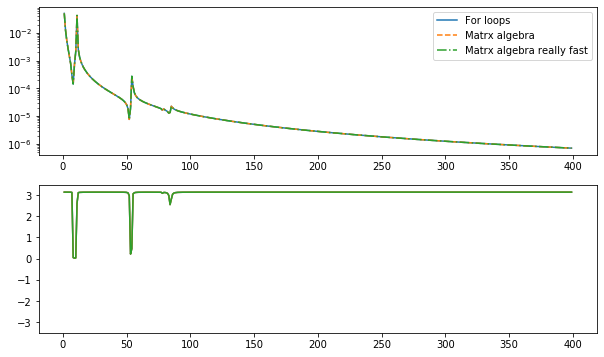

In [24]:
no_nodes_acc = np.array([1,])
orie_acc = "x"

no_nodes_exc = np.array([1,])
orie_exc = "x"

# ad_locations(view3D_loc_visualisation, nodes[selected_dense_mesh_node_index], no_nodes_acc, orie_acc, no_nodes_exc, orie_exc)

loc_1, loc_2 = loc_definition(no_nodes_acc[0], determinition_of_orientation(orie_acc, out_type="number"), 
                              no_nodes_exc[0], determinition_of_orientation(orie_exc, out_type="number"), False)
print(loc_1, loc_2)
plt.figure(figsize =(10,6))
plt.subplot(211)
plt.semilogy(freq,np.abs(H_z[:, loc_1, loc_2]),'-',label = "For loops")
plt.semilogy(freq,np.abs(FRF_matrix[:, loc_1, loc_2]),'--',label = "Matrx algebra")
plt.semilogy(freq,np.abs(FRF_matrix_2[:, loc_1, loc_2]),'-.',label = "Matrx algebra really fast")
plt.legend()
plt.subplot(212)
plt.plot(freq,np.angle(H_z[:, loc_1, loc_2]),'-')
plt.plot(freq,np.angle(FRF_matrix[:, loc_1, loc_2]),'-')
plt.plot(freq,np.angle(FRF_matrix_2[:, loc_1, loc_2]),'-')
plt.ylim(-3.5, 3.5)

In [25]:
eig_freq[6:10]/(2*np.pi)

array([10.95124089, 54.20109343, 78.26334109, 84.49538243])

In [26]:
np.allclose(FRF_matrix_2, H_z, equal_nan=True)

True